In [2]:
import pandas as pd
# загружаем данные
data = pd.read_csv("ab_results.csv")

grouped_data = (data
    .groupby("treatment")['target']
    .agg(["mean"])
)
print(data.info())
print(grouped_data)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 9 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   usage_duration                   400000 non-null  float64
 1   number_of_bank_cards             400000 non-null  int64  
 2   money_spent_amount               400000 non-null  float64
 3   visit_frequency                  400000 non-null  float64
 4   number_of_visited_shops          400000 non-null  int64  
 5   number_of_viewed_communications  400000 non-null  int64  
 6   age                              400000 non-null  float64
 7   treatment                        400000 non-null  int64  
 8   target                           400000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 27.5 MB
None
               mean
treatment          
0          0.193715
1          0.293995


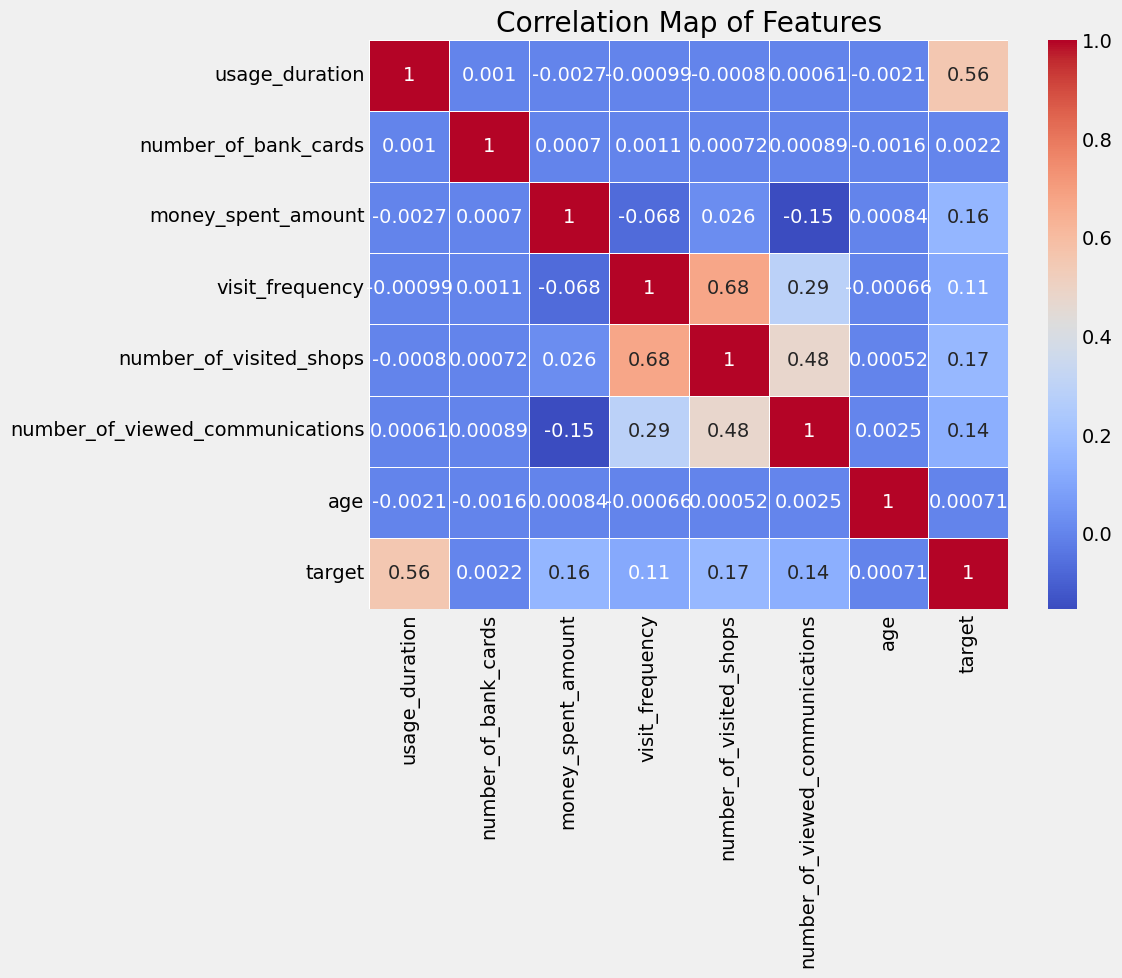

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# загружаем данные
data = pd.read_csv("ab_results.csv")

plt.figure(figsize=(12, 10))
correlation_matrix = (data
                     .drop(columns=['treatment'])
                     .corr()
                    )
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Map of Features')
plt.tight_layout()
plt.show()

In [5]:
from causalml.inference.tree import UpliftRandomForestClassifier
import pandas as pd

# загрузка датасета
data = pd.read_csv("ab_results.csv")

# разделение на признаки и целевую переменную
X = data.drop(['target'], axis=1)
y = data['target']


uniq_y = y.unique()
print(uniq_y)

[0 1]


In [14]:
X['treatment'] = X['treatment'].map({
    0: 'control',
    1: 'treatment'
})

In [15]:
from sklearn.model_selection import train_test_split
# разделение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)


# создаём модель Uplift Random Forest, указывая название контрольной группы
uplift_model = UpliftRandomForestClassifier(control_name='control')

uplift_model.fit(X_train.drop(columns=['treatment']).values,
                 treatment=X_train['treatment'].values,
                 y=y_train.values)

In [16]:
# предсказываем uplift (эффект воздействия) на валидационной выборке
uplift_scores = uplift_model.predict(X_val.drop(columns=['treatment']), full_output=False)

print(uplift_scores)

[[0.02903858]
 [0.72499871]
 [0.0414781 ]
 ...
 [0.02047342]
 [0.02047342]
 [0.96997662]]


In [17]:
import numpy as np
top_percent = 0.05

# сортируем массив в убывающем порядке
top_5_percent = np.sort(uplift_scores)[::-1][:int(len(uplift_scores) * top_percent)]

print(f"Количество клиентов в верхних 5%: {len(top_5_percent)}")
print(f"Минимальное значение uplift в верхних 5%: {np.min(top_5_percent):.2f}")
print(f"Максимальное значение uplift в верхних 5%: {np.max(top_5_percent):.2f}")
print(f"Среднее значение uplift: {np.mean(top_5_percent):.2f}")


Количество клиентов в верхних 5%: 6000
Минимальное значение uplift в верхних 5%: 0.01
Максимальное значение uplift в верхних 5%: 0.98
Среднее значение uplift: 0.10


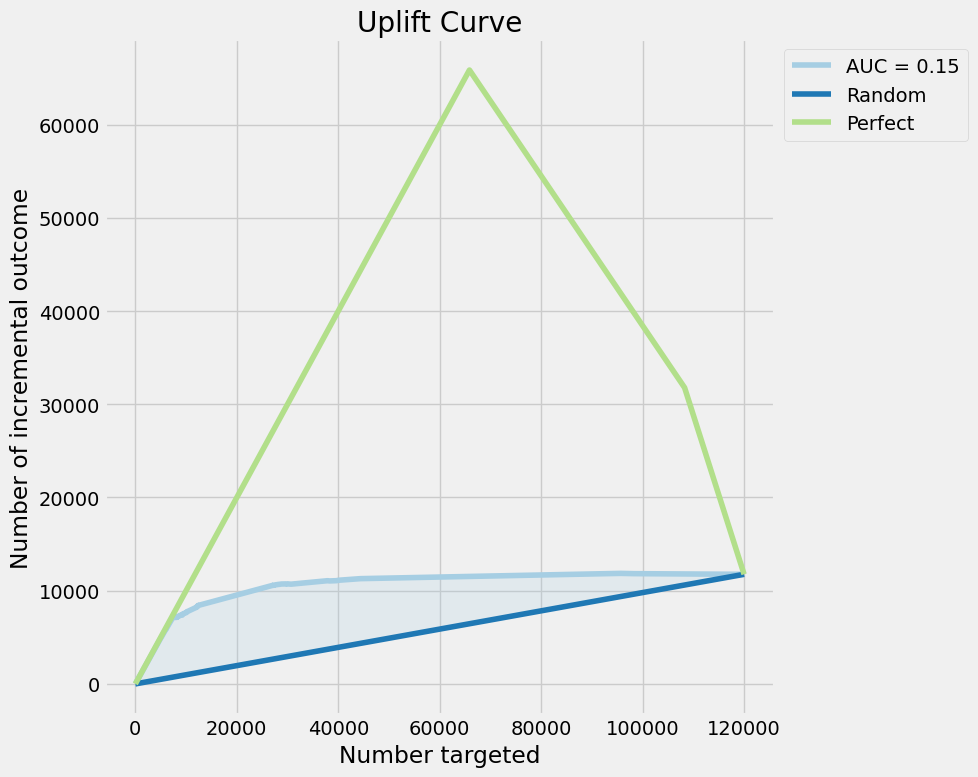

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklift.viz import plot_uplift_curve

# загрузите predictions.csv
uplift_preds = pd.read_csv('predictions_less4.csv')
treatment = X_val['treatment']

treatment_mapping = {
    'control': 0, 
     'treatment': 1,  
}

#  применяем маппинг к столбцу treatment
treatment = treatment.map(treatment_mapping)


fig, axs = plt.subplots(1, 1, figsize=(10, 8))

plot_uplift_curve(y_val, uplift_preds.values.squeeze(), treatment, ax=axs)
axs.set_title('Uplift Curve')
axs.grid(True)

plt.tight_layout()
plt.show()


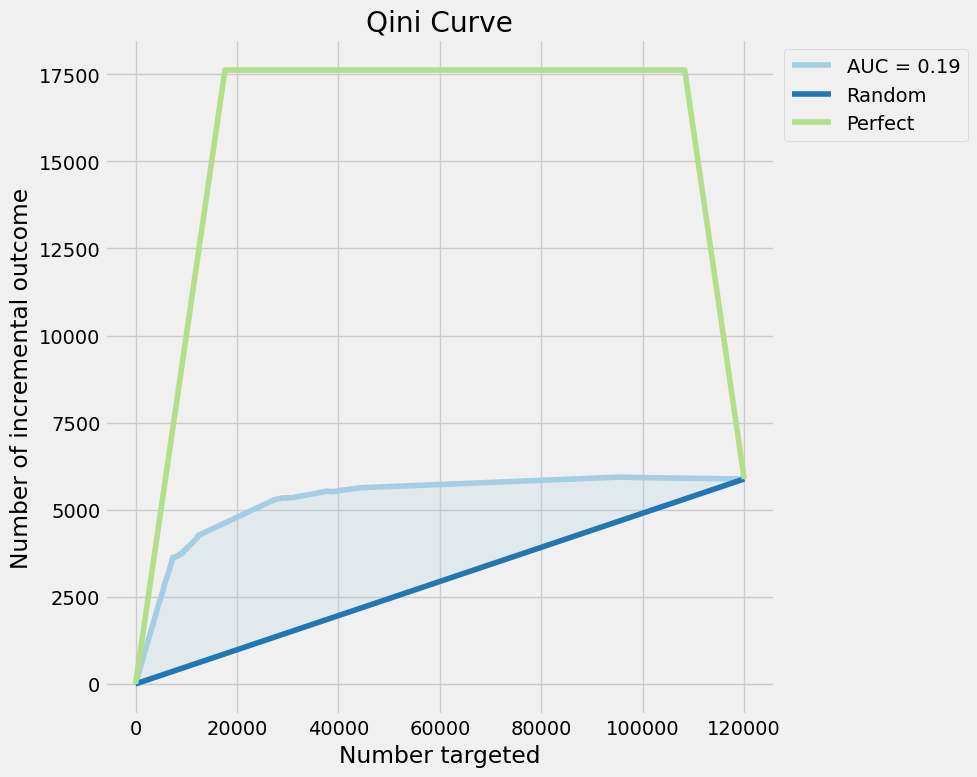

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklift.viz import plot_qini_curve


fig, axs = plt.subplots(1, 1, figsize=(10, 8))

plot_qini_curve(y_val, uplift_preds.values.squeeze(), treatment, ax=axs)
axs.set_title('Qini Curve')
axs.grid(True)

plt.tight_layout()
plt.show()
